# Machine Learning for Single-Cell Biology
***

Winter Semester 2025/26<br />
Manfred Claassen, Maximilian Wirth, Jan Schleicher
<br />
***

## Assignment 3

In [94]:
import numpy as np
import pandas as pd
import umap
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import FactorAnalysis
import os
from matplotlib import pyplot as plt
import seaborn as sns

from typing import List, Union, Tuple

sns.set_style("ticks")
%matplotlib inline

In [95]:
DATA_PATH = "data/"
OUTPUT_PATH = "output/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

### Task 1

In [96]:
def task1a_get_mean_per_cell_type(expression_df: pd.DataFrame,
                                  cell_type_df: pd.DataFrame,
                                  gene_list: List[str],
                                  cell_type_col: str = "cell_type") -> pd.DataFrame:
    """
    Compute the mean expression per cell type from a single-cell expression matrix.
    :param expression_df: A DataFrame of shape (n_cells, n_genes) containing the expression data.
    :param cell_type_df: A DataFrame of shape (n_cells, n_annotations) containing metadata (including cell type).
    :param gene_list: A list of marker genes for which to compute mean expression.
    :param cell_type_col: The name of the column in cell_type_df that contains cell type annotations.
    :return: A DataFrame of shape (n_cell_types, n_markers) with the mean expression per cell type for the given genes.
    """
    cell_type_means = pd.DataFrame(index=cell_type_df[cell_type_col].astype("category").cat.categories,
                                   columns=gene_list,
                                   dtype=float)
    #########################
    # filter for cell_types and compute for each the mean gene_expression -> collect into cell_type_means dataframe
    for cell_type in cell_type_df["cell_type"].astype("category").cat.categories: 
        for gene in gene_list:
           cell_type_means.loc[cell_type, gene] = np.mean(expression_df.loc[cell_type_df["cell_type"] == cell_type, gene])

    
    # expression_means = [np.mean(expression_df[gene]) for gene in gene_list]
    print(cell_type_means)
  
    #########################
    return cell_type_means

In [97]:
def task1a_plot_heatmap(cell_type_means: pd.DataFrame) -> None:
    """
    Plot a heatmap displaying mean expression per cell type.
    :param cell_type_means: A DataFrame of shape (n_cell_types, n_markers) with the mean expression per cell type.
    :return:
    """
    #########################

    plt.figure(figsize=(11,3))   
    plt.title("Heatmap of mean gene expression per cell type", fontsize=14) 
    plt.xlabel("Marker genes")
    plt.ylabel("Cell types")
    sns.heatmap(cell_type_means, annot=True, cmap="Reds", annot_kws={"size":8})
    plt.show()

    #########################
    return None

In [98]:
def task1c_compute_umap(expression_df: pd.DataFrame) -> np.ndarray:
    """
    Compute a UMAP embedding of the expression data.
    :param expression_df: A Dataframe of shape (n_cells, n_genes) containing the expression data.
    :return: An array of shape (n_cells, 2) containing the embedding coordinates.
    """
    embedding = np.zeros((expression_df.shape[0], 2))
    #########################
    umap_computation = umap.UMAP(random_state=42)
    embedding = umap_computation.fit_transform(expression_df)

    #########################
    return embedding

In [99]:
# Load data
expression_data = pd.read_csv(os.path.join(DATA_PATH, "expression_data_1.txt"), sep="\t", index_col=0)
cell_type_data = pd.read_csv(os.path.join(DATA_PATH, "cell_type_data_1.txt"), sep="\t", index_col=0)

        CCR7      CD14      IL7R    S100A4     MS4A1      CD8A    FCGR3A  \
B   0.450050  0.013957  0.087897  0.521108  1.944864  0.019383  0.010428   
MP  0.001695  1.488222  0.014098  3.201191  0.004345  0.003538  0.155906   
NK  0.086120  0.014691  0.714987  2.638310  0.024411  0.648337  0.917810   

       MS4A7      NKG7    FCER1A      PPBP  
B   0.024018  0.040478  0.000000  0.003125  
MP  0.225230  0.075358  0.001059  0.023283  
NK  0.001588  3.152994  0.001931  0.002862  


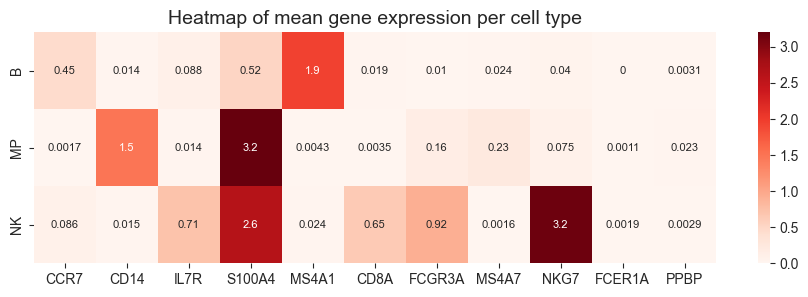

In [100]:
# Get mean expression of marker genes per cell type
marker_genes = ["CCR7", "CD14", "IL7R", "S100A4", "MS4A1", "CD8A", "FCGR3A", "MS4A7", "NKG7", "FCER1A", "PPBP"]
mean_expression = task1a_get_mean_per_cell_type(expression_df=expression_data,
                                                cell_type_df=cell_type_data,
                                                gene_list=marker_genes)


task1a_plot_heatmap(mean_expression)

**Provide your text answers for Task 1B here**

Since a marker gene will be used to identify the cell_type, these gene must be expressed higher with a certain cell type, while other genes have lower expression here.

**For cell type B:** we choose gene _MS4A1_ since this is most highly expressed here

**For cell type MP:** we choose gene _CD14_ and *not* _S100A4_, because even though _S100A4_ has higher expression, NK also shows higher expression for this gene.

**For cell type NK:** we choose gene _NK67_, since it hs the highest expression level and no other cell_type has high expression on this gene

=> These genes can now be used for identification

In [101]:
# Compute UMAP
umap_coords = task1c_compute_umap(expression_df=expression_data)

c:\Users\Anwender\Desktop\Uni_Tuebingen\Master\1. Semester\ML Single Cell\Assignments\Assignment03\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


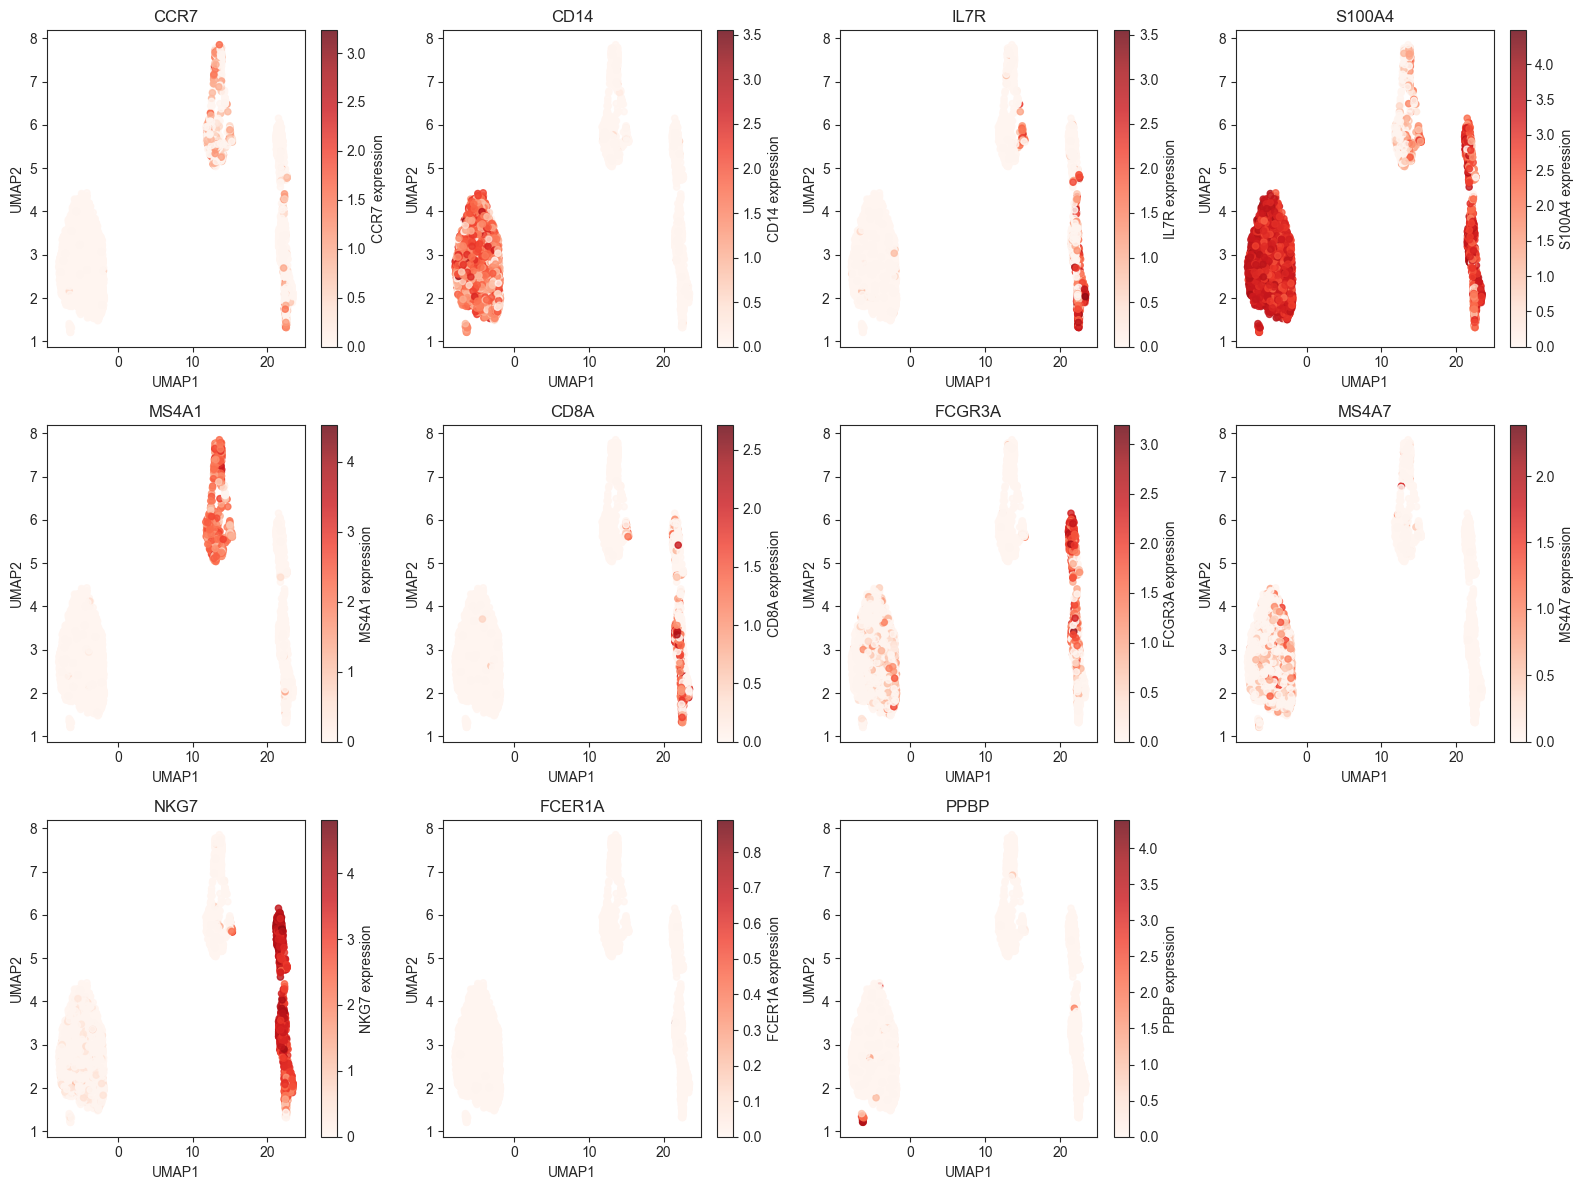

In [102]:
# Plot UMAPs with gene expression
#########################
# for gene in marker_genes:
#     plt.figure(figsize=(6,5))
#     plt.scatter(umap_coords[:,0], umap_coords[:,1], c=expression_data[gene], cmap="Reds", s=20, alpha=0.8)
#     plt.colorbar(label=f"{gene} expression")
#     plt.xlabel("UMAP1")
#     plt.ylabel("UMAP2")
#     plt.title(f"UMAP projection colored by {gene}")
#     plt.show()

n_markers = len(marker_genes)
n_cols = 4
n_rows = (n_markers + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten()

for i, gene in enumerate(marker_genes):
    ax = axes[i]
    sc = ax.scatter(
        umap_coords[:,0], umap_coords[:,1],
        c=expression_data[gene],
        cmap="Reds",
        s=20,
        alpha=0.8
    )
    ax.set_title(gene)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    fig.colorbar(sc, ax=ax, label=f"{gene} expression")

# leere Subplots entfernen, falls n_markers < n_rows*n_cols
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#########################

### Task 2

In [103]:
def task2a_differential_expression_testing(expression_df: pd.DataFrame,
                                           cell_type_df: pd.DataFrame,
                                           cell_type_col: str = "cell_type") -> pd.DataFrame:
    """
    Perform a differential expression analysis between cell types.
    :param expression_df: A Dataframe of shape (n_cells, n_genes) containing the expression data.
    :param cell_type_df: A DataFrame of shape (n_cells, n_annotations) containing metadata (including cell type).
    :param cell_type_col: The name of the column in cell_type_df that contains cell type annotations.
    :return: A DataFrame with the results of differential expression testing.
    """
    de_results = pd.DataFrame(columns=pd.MultiIndex.from_product([cell_type_df[cell_type_col].unique(),
                                                                  ["p", "logFC", "p_adj"]]),
                              index=expression_df.columns)
    # stats.mannwhitneyu
    #########################
    # INSERT YOUR CODE HERE #
    #########################
    return de_results

In [104]:
# Perform differential expression analysis
de_genes = task2a_differential_expression_testing(expression_df=expression_data,
                                                  cell_type_df=cell_type_data)
de_genes.to_csv(os.path.join(OUTPUT_PATH, "de_results.tsv"), sep="\t")

**Provide your text answers for Task 2B here**

### Task 3

In [105]:
def task3a_factor_analysis(expression_df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
    """
    Perform factor analysis on the expression data.
    :param expression_df: A Dataframe of shape (n_cells, n_genes) containing the expression data.
    :return: An array with factor activities of shape (n_cells, n_factors) and
    an array with gene loadings of shape (n_factors, n_genes).
    """
    # fa = FactorAnalysis(n_components=3)

    factor_activity = np.zeros((expression_df.shape[0], 3))
    gene_loadings = np.zeros((3, expression_df.shape[1]))

    #########################
    # INSERT YOUR CODE HERE #
    #########################

    return factor_activity, gene_loadings

In [106]:
# Run factor analysis
factor_activities, gene_loadings = task3a_factor_analysis(expression_df=expression_data)

In [107]:
# Plot factor activity on UMAP (you can use the function from Task 1C)
#########################
# INSERT YOUR CODE HERE #
#########################

**Provide your text answers for Task 3A here**

In [108]:
# Export loadings
loadings_df = pd.DataFrame(gene_loadings.T,
                           index=expression_data.columns,
                           columns=[f"factor_{i+1}" for i in range(gene_loadings.shape[0])])
loadings_df.to_csv(os.path.join(OUTPUT_PATH, "fa_gene_loadings.tsv"), sep="\t", header=True, index=True)

**You may perform GSEA with any python tool, but you can also use some online tool if you prefer that. Just make sure to submit the results.**

In [109]:
# Gene set enrichment analysis
#########################
# INSERT YOUR CODE HERE #
#########################

**Provide your text answers for Task 3B here**